# Sessionization & Feature Engineering

Transforms the raw RetailRocket event log into a session-level feature table:
one row per session, with engineered features as input columns and `purchased` as the target.

## Contents
0. Summary

1. Load the event log
2. Sessionisation
3. Session-level statistics
4. Feature engineering
5. Feature distributions
6. Class balance
7. Correlation with target
8. Export

## Summary

| | |
|---|---|
| Sessions | ~1,761,675 |
| Features | 9 |
| Target | `purchased` (binary, 0 / 1) |
| Purchase rate | 0.81 % — imbalance ratio ~1:122 |
| Output | `data/sessions_features.parquet` |

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.join('..', 'src'))
from session_utils import load_events, assign_session_ids, build_session_features

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')

## 1. Load the Event Log

We use `load_events()` from `src/session_utils.py`, which:
- reads the CSV
- parses the Unix millisecond timestamp to a proper datetime
- sorts by `visitorid` then `timestamp` (required for correct session assignment)

In [26]:
df = load_events(os.path.join(DATA_DIR, 'events.csv'))
print(f'Rows   : {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows   : 2,756,101
Columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']


,timestamp,visitorid,event,itemid,transactionid
0,2015-09-11 20:49:49.439,0,view,285930,NaN
1,2015-09-11 20:52:39.591,0,view,357564,NaN
2,2015-09-11 20:55:17.175,0,view,67045,NaN
3,2015-08-13 17:46:06.444,1,view,72028,NaN
4,2015-08-07 17:51:44.567,2,view,325215,NaN


## 2. Sessionisation

A new session starts when a visitor has been inactive for more than 30 minutes
(the Google Analytics standard). `assign_session_ids()` adds a `session_id`
column using this time-gap rule:

```
event stream:  e1  e2  e3  ···  e4  e5
time gaps:         2m  4m  │31m  1m
                           ▼
session_ids:    1   1   1  │  2   2
```


In [27]:
df = assign_session_ids(df)

n_sessions = df['session_id'].nunique()
n_visitors = df['visitorid'].nunique()
print(f'Events         : {len(df):,}')
print(f'Sessions       : {n_sessions:,}')
print(f'Visitors       : {n_visitors:,}')
print(f'Sessions/visitor (mean): {n_sessions / n_visitors:.2f}')

# Show an example: all events of one visitor, with session IDs assigned
example_visitor = df[df['visitorid'] == df['visitorid'].unique()[5]]
print(f'\nExample — visitor {example_visitor["visitorid"].iloc[0]}:')
example_visitor[['timestamp', 'event', 'itemid', 'session_id']].head(10)

Events         : 2,756,101
Sessions       : 1,761,675
Visitors       : 1,407,580
Sessions/visitor (mean): 1.25

Example — visitor 5:


,timestamp,event,itemid,session_id
14,2015-07-17 01:45:56.439,view,61396,6


## 3. Session-Level Statistics

Before building features, it helps to understand the distribution of session lengths.
Most sessions are very short (1–2 events). A long tail exists but is less common.

In [28]:
events_per_session = df.groupby('session_id').size()

print('Events per session:')
print(events_per_session.describe().round(1))

Events per session:
count    1761675.0
mean           1.6
std            2.6
min            1.0
25%            1.0
50%            1.0
75%            1.0
max          417.0
dtype: float64


## 4. Feature Engineering

We aggregate each session into a single row with numeric features.
`build_session_features()` in `src/session_utils.py` handles this.

**Features and their rationale:**

| Feature | Type | Why it matters |
|---|---|---|
| `n_views` | int | Raw engagement — how many products the visitor looked at |
| `n_addtocart` | int | Direct purchase signal — adding to cart indicates intent |
| `n_items` | int | Breadth of interest — browsing many vs. few items |
| `n_revisited_items` | int | Returning to the same item suggests stronger intent |
| `duration_sec` | float | Overall session length — highly engaged sessions last longer |
| `hour_of_day` | int | Purchase intent varies by time of day |
| `day_of_week` | int | Weekday vs. weekend browsing behaviour differs |
| `view_to_cart_ratio` | float | n_addtocart / n_views — how decisive the visitor is |
| `is_first_session` | int | First-time visitors behave differently from returning ones |

**What we deliberately excluded:**
- `n_events` — it equals `n_views + n_addtocart + n_transactions` exactly. Including it adds no new information and creates multicollinearity.
- `has_addtocart` — it is 100 % derivable from `n_addtocart > 0`. One of them is redundant.

In [29]:
sessions = build_session_features(df)
print(f'Shape: {sessions.shape}  →  {sessions.shape[0]:,} sessions × {sessions.shape[1]} columns')
sessions.head()

Shape: (1761675, 12)  →  1,761,675 sessions × 12 columns


,session_id,visitorid,n_views,n_addtocart,n_items,duration_sec,purchased,n_revisited_items,hour_of_day,day_of_week,view_to_cart_ratio,is_first_session
0,1,0,3,0,3,327.736,0,0,20,4,0.0,1
1,2,1,1,0,1,0.000,0,0,17,3,0.0,1
2,3,2,8,0,4,1753.278,0,3,17,4,0.0,1
3,4,3,1,0,1,0.000,0,0,7,5,0.0,1
4,5,4,1,0,1,0.000,0,0,21,1,0.0,1


In [30]:
# Descriptive statistics for all numeric features
# Note the high std and max values — most features are heavily right-skewed
sessions.describe().round(2)

,session_id,visitorid,n_views,n_addtocart,n_items,duration_sec,purchased,n_revisited_items,hour_of_day,day_of_week,view_to_cart_ratio,is_first_session
count,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.00,1761675.0
mean,880838.00,703923.84,1.51,0.04,1.33,105.24,0.01,0.14,12.69,2.78,0.01,0.8
std,508551.91,406505.80,2.35,0.40,1.78,499.53,0.09,0.52,7.85,1.97,0.14,0.4
min,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
25%,440419.50,351654.50,1.00,0.00,1.00,0.00,0.00,0.00,4.00,1.00,0.00,1.0
50%,880838.00,704207.00,1.00,0.00,1.00,0.00,0.00,0.00,16.00,3.00,0.00,1.0
75%,1321256.50,1056079.50,1.00,0.00,1.00,0.00,0.00,0.00,20.00,4.00,0.00,1.0
max,1761675.00,1407579.00,417.00,114.00,389.00,43704.25,1.00,98.00,23.00,6.00,36.00,1.0


## 5. Feature Distributions

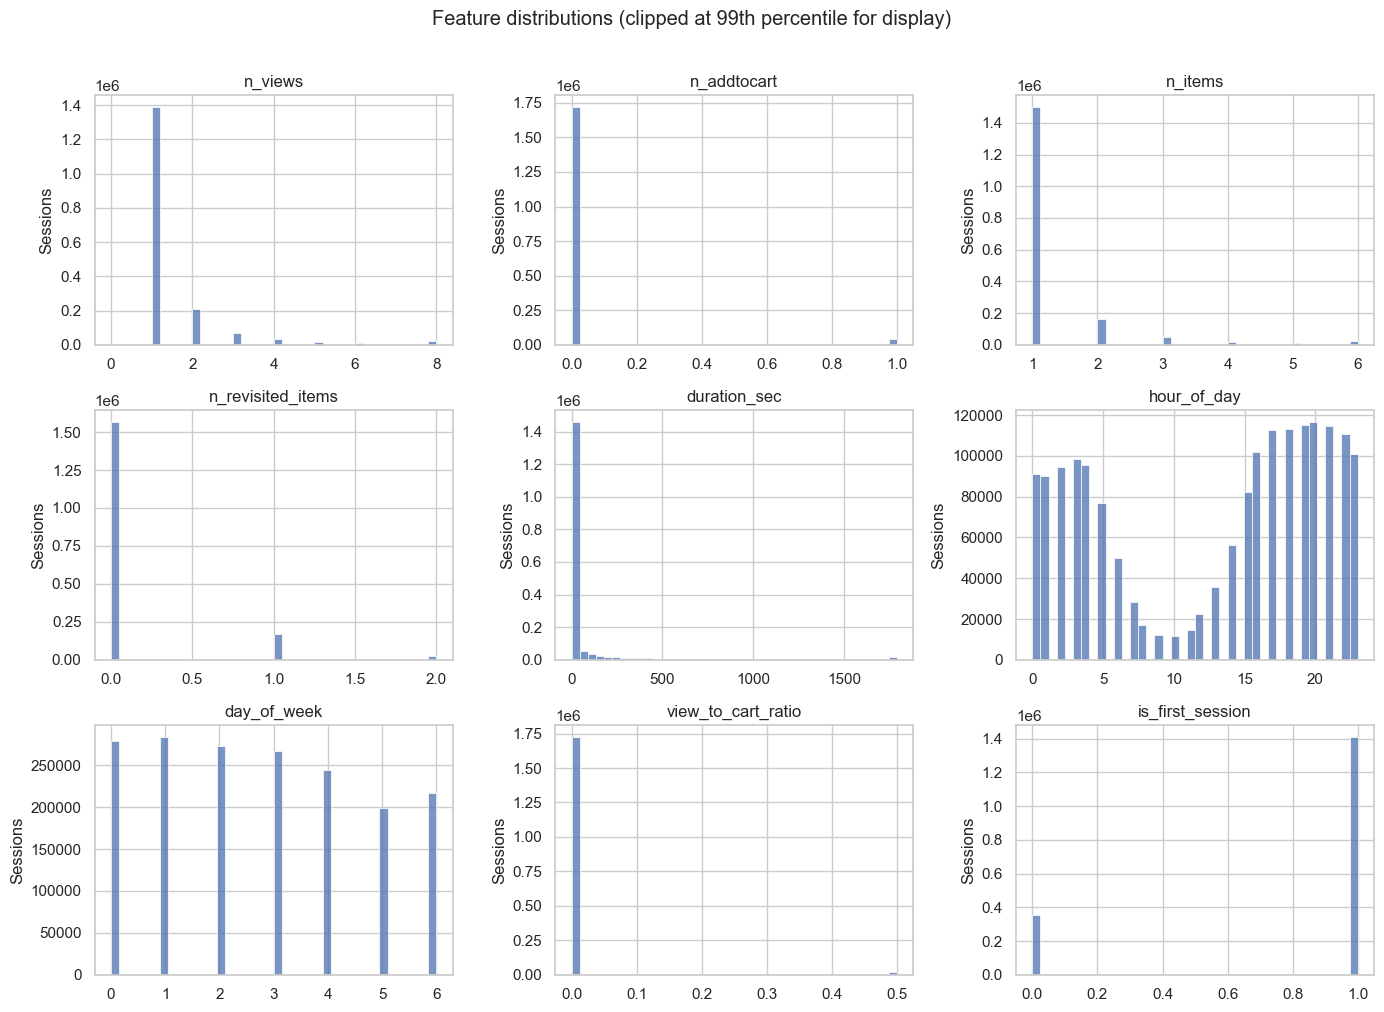

In [31]:
FEATURES = [
    'n_views', 'n_addtocart', 'n_items', 'n_revisited_items',
    'duration_sec', 'hour_of_day', 'day_of_week',
    'view_to_cart_ratio', 'is_first_session',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, FEATURES):
    data = sessions[col].clip(upper=sessions[col].quantile(0.99))
    sns.histplot(data, bins=40, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Sessions')

plt.suptitle('Feature distributions (clipped at 99th percentile for display)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Class Balance

The target column `purchased` is binary:
- **0** — the session did not end in a purchase
- **1** — the session contained at least one transaction event

With ~0.81 % positive class, this is a heavily imbalanced classification problem.
A naive classifier that always predicts "no purchase" would achieve 99.19 % accuracy —
which is why accuracy is not a useful metric here. We will use **PR-AUC** and **F1** instead.

The bars below are on a **log scale** because on a linear scale the minority class bar
is barely a pixel tall at this ratio (1:122).

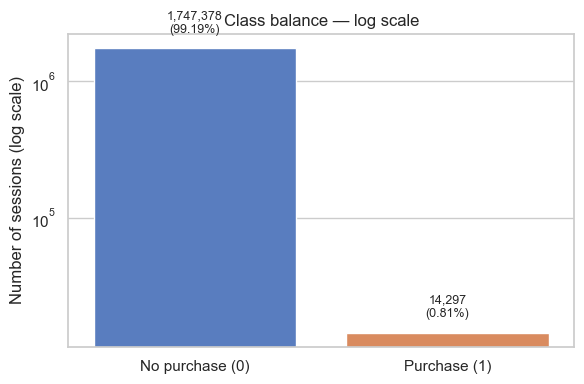

In [32]:
n_purchase = sessions['purchased'].sum()
n_no_purchase = len(sessions) - n_purchase
pct = (n_purchase / len(sessions)) * 100

balance_df = pd.DataFrame({
    'Class': ['No purchase (0)', 'Purchase (1)'],
    'Sessions': [n_no_purchase, n_purchase],
    'Share (%)': [round(100 - pct, 2), round(pct, 2)],
})

# Log scale is necessary — the two bars differ by a factor of ~120.
# On a linear scale, the minority class bar would be nearly invisible.
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=balance_df, x='Class', y='Sessions', hue='Class',
            palette='muted', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Class balance — log scale')
ax.set_ylabel('Number of sessions (log scale)')
ax.set_xlabel('')
for i, row in balance_df.iterrows():
    ax.text(i, row['Sessions'] * 1.3,
            f"{row['Sessions']:,}\n({row['Share (%)']:.2f}%)",
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Correlation with Target

Pearson (point-biserial) correlation between each feature and the binary target.
Note: this only captures linear relationships — a feature with low Pearson correlation
can still be important inside a tree-based model.


Correlation with target (purchased):
n_addtocart           0.3366
duration_sec          0.2936
view_to_cart_ratio    0.2812
n_views               0.1821
n_revisited_items     0.1757
n_items               0.1717
hour_of_day           0.0124
day_of_week          -0.0118
is_first_session     -0.0616
Name: purchased, dtype: float64


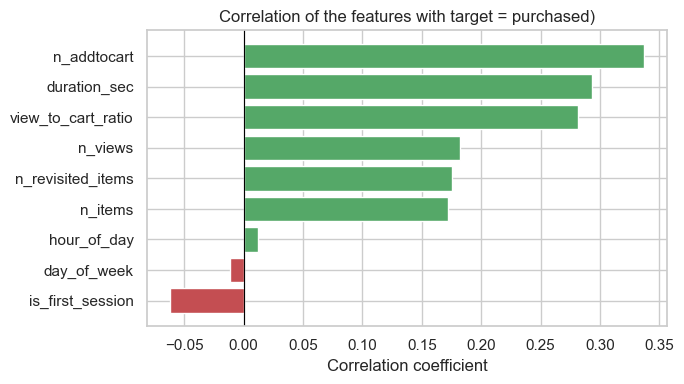

In [35]:
# Point-biserial correlation between each feature and the binary target.
# This is mathematically equivalent to Pearson when one variable is binary,
# but it's worth noting the limitation: it only captures linear relationships.
# A feature with low Pearson correlation can still be useful in a tree-based model.

corr = (
    sessions[FEATURES + ['purchased']]
    .corr()['purchased']
    .drop('purchased')
    .sort_values(ascending=False)
)
print('Correlation with target (purchased):')
print(corr.round(4))

# Use matplotlib barh directly — per-bar colors require it.
# seaborn's palette parameter maps categories, not individual values.
colors = ['#55A868' if v > 0 else '#C44E52' for v in corr.values]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of the features with target = purchased)')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
# Export
out_path = os.path.join(DATA_DIR, 'sessions_features.parquet')
sessions.to_parquet(out_path, index=False)
print(f'Saved to {out_path}')
print(f'Final shape: {sessions.shape}  →  {sessions.shape[1]-1} features + 1 target')

Saved to ../data/sessions_features.parquet
Final shape: (1761675, 12)  →  11 features + 1 target
